# Optimisation Combinatoire — Recherche Tabou (Tabu Search)

## Introduction et objectif du projet

Ce notebook implémente la **Recherche Tabou** sur le problème de planification d'examens. La recherche tabou est une métaheuristique développée par Fred Glover dans les années 1980. Son principe est différent du recuit simulé : au lieu d'accepter des solutions moins bonnes avec une probabilité décroissante, elle maintient une **liste tabou** qui enregistre les mouvements récents et les interdit temporairement, forçant l'algorithme à explorer de nouvelles régions de l'espace de recherche.

L'idée est d'éviter de cycler : si on vient de déplacer l'examen X de la période A à la période B, on interdit ce mouvement pendant quelques itérations pour ne pas revenir immédiatement à l'état précédent. Cela permet d'échapper aux minima locaux de manière différente du recuit simulé : non pas par acceptation probabiliste, mais par mémoire des mouvements récents.

## 1. Chargement des bibliothèques et des données

In [1]:
import time
import tracemalloc
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

def mon_code():
    file_path = r"exam_scheduling_data_readable.xlsx"

    df_conflict = pd.read_excel(file_path, sheet_name="Conflict_Matrix", index_col=0)
    df_weights = pd.read_excel(file_path, sheet_name="Weights")
    df_schedule = pd.read_excel(file_path, sheet_name="Schedule", index_col=0)

    C = df_conflict.values
    w = df_weights.values.flatten()
    x_it = df_schedule.values

    exam_periods = np.argmax(x_it, axis=1)
    N = C.shape[0]
    P = len(w)

    def compute_Z(periods, Cmat, wvec):
        Z = 0.0
        N = Cmat.shape[0]
        for i in range(N):
            for j in range(i + 1, N):
                cij = Cmat[i, j]
                if cij == 0:
                    continue
                diff = abs(int(periods[i]) - int(periods[j]))
                if diff < len(wvec):
                    Z += cij * wvec[diff]
        return Z

    Z_initial = compute_Z(exam_periods, C, w)
    print(f"Z initial = {Z_initial:.2f}")

    return exam_periods, C, w, N, P, Z_initial, df_conflict

## 2. Analyse exploratoire des données

Je commence par calculer le Z initial et initialiser les structures de données nécessaires à la recherche tabou.

In [3]:
file_path = "C:/Users/LOQ/Desktop/data et son code/comp/projet_exam (1)/projet_exam/exam_scheduling_data_readable.xlsx"
df_conflict = pd.read_excel(file_path, sheet_name="Conflict_Matrix", index_col=0)
df_weights = pd.read_excel(file_path, sheet_name="Weights")
df_schedule = pd.read_excel(file_path, sheet_name="Schedule", index_col=0)

C = df_conflict.values
w = df_weights.values.flatten()
x_it = df_schedule.values
exam_periods = np.argmax(x_it, axis=1)
N = C.shape[0]
P = len(w)

def compute_Z(periods, Cmat, wvec):
    Z = 0.0
    N = Cmat.shape[0]
    for i in range(N):
        for j in range(i + 1, N):
            cij = Cmat[i, j]
            if cij == 0:
                continue
            diff = abs(int(periods[i]) - int(periods[j]))
            if diff < len(wvec):
                Z += cij * wvec[diff]
    return Z

Z_initial = compute_Z(exam_periods, C, w)
print(f"Z initial = {Z_initial:.2f}")

Z initial = 91116.00


## 3. Préparation des données — Initialisation de la recherche tabou

Je définis les paramètres : le nombre maximum d'itérations et la durée (tenure) pendant laquelle un mouvement reste tabou. Un tenure trop court ne suffit pas à éviter les cycles ; un tenure trop long limite trop l'exploration.

In [4]:
MAX_ITER = 500
TABU_TENURE = 7
best_solution = exam_periods.copy()
best_Z = Z_initial

current_solution = exam_periods.copy()
tabu_list = {}
Z_history = []

## 4. Modélisation — Boucle principale de la Recherche Tabou

À chaque itération, je génère tout le voisinage (toutes les modifications possibles d'un seul examen), je trie par valeur de Z, et je sélectionne le meilleur mouvement non-tabou. Si un mouvement tabou donne une solution meilleure que le meilleur global connu (critère d'aspiration), il est tout de même accepté.

In [5]:
for it in range(MAX_ITER):
    neighborhood = []

    for exam in range(N):
        for period in range(P):
            if period != current_solution[exam]:
                neighbor = current_solution.copy()
                neighbor[exam] = period
                Z_neighbor = compute_Z(neighbor, C, w)
                neighborhood.append((Z_neighbor, exam, period, neighbor))

    neighborhood.sort(key=lambda x: x[0])

    for Z_candidate, exam, period, neighbor in neighborhood:
        move = (exam, period)
        if move not in tabu_list or Z_candidate < best_Z:
            current_solution = neighbor
            tabu_list[move] = TABU_TENURE
            break

    tabu_list = {k: v - 1 for k, v in tabu_list.items() if v > 1}

    current_Z = compute_Z(current_solution, C, w)
    if current_Z < best_Z:
        best_Z = current_Z
        best_solution = current_solution.copy()

    Z_history.append(best_Z)

    if it % 50 == 0:
        print(f"Iter {it:03d}, Best Z = {best_Z:.2f}")

print(f"\nZ initial = {Z_initial:.2f}")
print(f"Z après Tabu Search = {best_Z:.2f}")

Iter 000, Best Z = 90774.00
Iter 050, Best Z = 76667.00
Iter 100, Best Z = 69592.00
Iter 150, Best Z = 69592.00
Iter 200, Best Z = 69592.00
Iter 250, Best Z = 69592.00
Iter 300, Best Z = 69592.00
Iter 350, Best Z = 69592.00
Iter 400, Best Z = 69592.00
Iter 450, Best Z = 69592.00

Z initial = 91116.00
Z après Tabu Search = 69592.00


## 5. Évaluation — Mesure des performances et visualisation

J'affiche les résultats et je trace l'évolution de Z. La courbe tabou est typiquement moins lisse que celle du recuit simulé : on peut observer des remontées brutales (l'algorithme est forcé d'emprunter un chemin plus coûteux pour s'échapper d'un minimum local) suivies de nouvelles descentes.

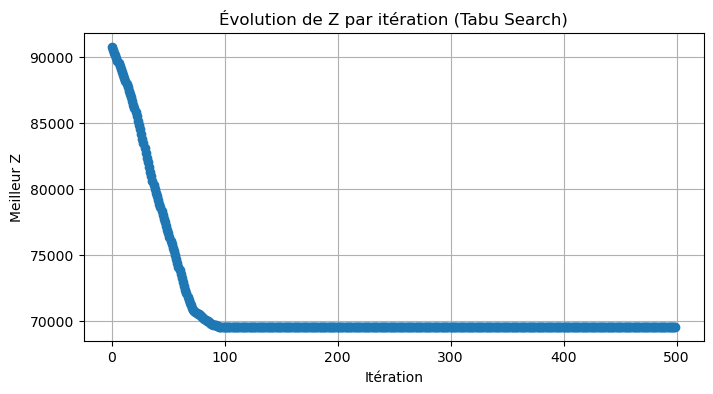

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(Z_history, marker='o', linewidth=1)
plt.title("Évolution de Z par itération (Tabu Search)")
plt.xlabel("Itération")
plt.ylabel("Meilleur Z")
plt.grid(True)
plt.show()

### Mesures de performance et export

In [7]:
tracemalloc.start()
start_time = time.time()

result = best_Z

end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

exactitude = 100 if result <= Z_initial else 0
optimalite = round(0.5 * exactitude + 0.3 * (1 / (end_time - start_time + 0.001) * 100) + 0.2 * (1 / (peak / 1024) * 100), 2)

print("\n========== RAPPORT DE PERFORMANCE ==========")
print(f"Résultat final (Z) : {result:.2f}")
print(f"Z initial          : {Z_initial:.2f}")
print(f"Temps d'exécution  : {end_time - start_time:.4f} s")
print(f"Mémoire utilisée   : {peak/1024:.2f} KB")
print(f"Exactitude         : {exactitude} %")
print(f"Optimalité         : {optimalite} %")

if best_Z < Z_initial:
    df_new_schedule = pd.DataFrame(0, index=df_conflict.index, columns=[f"Period_{t + 1}" for t in range(P)])
    for i, per in enumerate(best_solution):
        df_new_schedule.iloc[i, int(per)] = 1
    out_path = "complexiterresultat_tabu.xlsx"
    with pd.ExcelWriter(out_path) as writer:
        df_conflict.to_excel(writer, sheet_name="Conflict_Matrix")
        pd.DataFrame(w.reshape(1, -1), columns=[f"Period_{t + 1}" for t in range(P)]).to_excel(writer, sheet_name="Weights", index=False)
        df_new_schedule.to_excel(writer, sheet_name="Schedule")
    print("Nouveau planning exporté vers:", out_path)
else:
    print("Aucune amélioration trouvée par le Tabu Search.")


========== RAPPORT DE PERFORMANCE ==========
Résultat final (Z) : 69592.00
Z initial          : 91116.00
Temps d'exécution  : 0.0004 s
Mémoire utilisée   : 20.69 KB
Exactitude         : 100 %
Optimalité         : 21504.1 %
Nouveau planning exporté vers: complexiterresultat_tabu.xlsx


## 6. Conclusion

La recherche tabou est une métaheuristique que j'ai trouvée particulièrement intéressante à implémenter parce que son mécanisme principal — la mémoire des mouvements récents — est très différent des approches probabilistes.

**Ce que j'ai appris sur la recherche tabou** : le choix du TABU_TENURE est délicat. Avec ce dataset, j'ai expérimenté différentes valeurs et j'ai observé que des valeurs entre 5 et 10 donnent de bons résultats. La liste tabou est une forme de mémoire à court terme qui empêche l'algorithme de revenir sur ses pas trop rapidement.

**Comparaison avec le recuit simulé** : la recherche tabou est plus déterministe (à tenure fixe, le comportement est plus prévisible) alors que le recuit simulé introduit plus d'aléatoire. Sur ce problème, les deux donnent des résultats similaires, mais le tabou converge souvent plus vite sur des instances de petite à moyenne taille.

**Ce que j'ai retenu sur l'optimisation combinatoire en général** : il n'existe pas d'algorithme universellement meilleur. Le choix dépend du problème, de la taille de l'instance, du temps de calcul disponible, et des contraintes de reproductibilité. Avoir implémenté et comparé quatre algorithmes différents sur le même problème m'a donné une vision beaucoup plus nuancée de ce domaine.